## UBER DATA ANALYSIS PROJECT

#### Analyze Uber ride data to identify patterns in trip behavior, demand times, and usage trends.


Ride-sharing companies collect lots of data but struggle to use it effectively. This creates problems:
 
- **Poor resource planning** - Drivers aren't in the right place at the right time
- **Missed opportunities** - Can't identify the best times and routes for higher earnings
- **Incomplete data** - Missing information makes it hard to understand customer needs
- **No clear metrics** - Difficult to measure performance and improvement

## 1. Load the dataset and libraries

In [1]:
# Import core libraries for data analysis and visualisation
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid") # apply grid line to plots

In [2]:
# Load the Uber trips CSV file
df = pd.read_csv("UberDataset.csv")
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21.11,01-01-2016 21.17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 1.25,01-02-2016 1.37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20.25,01-02-2016 20.38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17.31,01-05-2016 17.45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14.42,01-06-2016 15.49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


## 2. Basic info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1155 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1155 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [4]:
df.describe() #summary statistics

,MILES
count,1155.000000
mean,10.566840
std,21.579106
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,310.300000


## 3. Data Cleaning

In [5]:
df['START_DATE'] = df['START_DATE'].str.replace('.', ':', regex=False)  #fix date format

In [6]:
df['START_DATE'] = df['START_DATE'].str.replace('/', '-', regex=False)

In [7]:
df['START_DATE'] = pd.to_datetime(df['START_DATE']) # convert to datetime

In [8]:
df['END_DATE'] = df['END_DATE'].str.replace('.', ':', regex=False)


In [9]:
df['END_DATE'] = df['END_DATE'].str.replace('/', '-', regex=False)


In [10]:
df['END_DATE'] = pd.to_datetime(df['END_DATE'])

In [11]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


### 3.1 Column Renaming
#### Fix all columns names to lower case

In [12]:
old_column_name = list(df.columns)


In [13]:
new_column_name = [i.lower() for i in old_column_name]
new_column_name

['start_date', 'end_date', 'category', 'start', 'stop', 'miles', 'purpose']

In [14]:
df.columns = new_column_name

In [15]:
df.head()

,start_date,end_date,category,start,stop,miles,purpose
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


#### 3.2 Duplicates removal

In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:
df.drop_duplicates(inplace = True)
print("Duplicates removed")

Duplicates removed


##  4.Trip Analysis

### 4.1 How many total trips were made?

In [18]:
df.shape[0]

1154

### 4.2 What is the average trip distance(in miles)?

In [19]:
df['miles'].mean().round(2)

np.float64(10.57)

### 4.3 Which city pairs (START ->  STOP) are most frequent routes?

In [20]:
#creating new column by combining existing columns
df['trip'] = df['start'].fillna('Unknown Location') + "-" + df['stop'].fillna('Unknown Location')


In [21]:
df.head()

,start_date,end_date,category,start,stop,miles,purpose,trip
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fort Pierce-Fort Pierce
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,Fort Pierce-Fort Pierce
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Fort Pierce-Fort Pierce
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Fort Pierce-Fort Pierce
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Fort Pierce-West Palm Beach


In [22]:
df['trip'].value_counts()

trip
Unknown Location-Unknown Location    86
Morrisville-Cary                     75
Cary-Morrisville                     67
Cary-Cary                            53
Cary-Durham                          36
                                     ..
Gampaha-Ilukwatta                     1
Flatiron District-Midtown             1
Cary-Unknown Location                 1
Unknown Location-Morrisville          1
Downtown-Central                      1
Name: count, Length: 363, dtype: int64

In [23]:
df[~df['trip'].str.contains("Unknown Location")]['trip'].value_counts().head(1)

trip
Morrisville-Cary    75
Name: count, dtype: int64

### 4.4 What is the most common trip purpose? (excluding missing/NaN values)

In [24]:
df[df['purpose'].notna()]['purpose'].value_counts().head(1)

purpose
Meeting    186
Name: count, dtype: int64

> #### Most common trip purpose is meeting

### 4.5 How many trips were made each month? Which month had the most trips?

In [25]:
df['month'] = df['start_date'].dt.month_name()

In [26]:
df['month'].value_counts()

month
December     146
August       133
November     122
February     115
March        113
July         112
June         107
October      106
January       61
April         54
May           49
September     36
Name: count, dtype: int64

### 4.6 How many trips were made for each CATEGORY ( example- Business vs Personal)?

In [27]:
df['category'].unique()

array(['Business', 'Personal'], dtype=object)

In [28]:
df['category'].value_counts()

category
Business    1077
Personal      77
Name: count, dtype: int64

### 4.7 What is the average trip duration in minutes? (Use END_DATE - START_DATE)

In [29]:
df['duration'] = (df['end_date'] - df['start_date']).dt.total_seconds() / 60

In [30]:
df['duration'].mean()


np.float64(23.241767764298093)

### 4.8 what percentage of trips have missing Purpose values?

In [31]:
(df['purpose'].isna().mean() * 100).round(2)

np.float64(43.5)

### 4.9 which day of the week has the highest number of trips?


In [32]:
df['week_name'] = df['start_date'].dt.day_name()

In [33]:
df['week_name'].value_counts()

week_name
Friday       206
Tuesday      175
Monday       174
Thursday     154
Saturday     150
Sunday       148
Wednesday    147
Name: count, dtype: int64


> ### Average trip duration = 23.24 minutes
> ### Most trips happened on Friday
> ### Month-wise highest count was December
> ### 43.5 % has missing purpose values

### 4.10 Top Locations

In [34]:
df['start'].value_counts().head(10)

start
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               36
Lahore               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

### 4.11 what is the total and average distance traveled per purpose type?

In [35]:
df.groupby("purpose")['miles'].agg(['sum','mean']).round(2).sort_values(by='sum',ascending=False)

,sum,mean
purpose,,
Meeting,2841.4,15.28
Customer Visit,2089.5,20.69
Meal/Entertain,911.7,5.70
Temporary Site,523.7,10.47
Errand/Supplies,508.0,3.97
Between Offices,197.0,10.94
Commute,180.2,180.20
Moving,18.2,4.55
Airport/Travel,16.5,5.50


### 4.12 How has the number of trips changed over time (monthly trend)?

In [36]:
df['month_number'] = df['start_date'].dt.month

In [37]:
trip = df.groupby("month_number")['month_number'].count()

In [38]:
trip = pd.DataFrame( trip)

In [39]:
trip.rename(columns={"month_number": "current_month"}, inplace=True)
trip['previous_month'] = trip['current_month'].shift(1)

In [40]:
trip['change'] = trip['current_month'] - trip['previous_month']

<Axes: xlabel='month_number'>

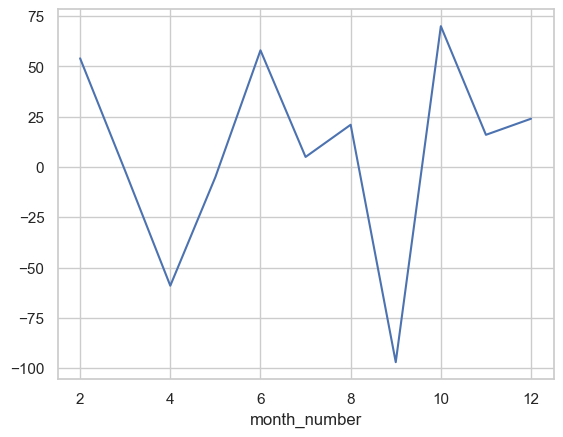

In [41]:
trip['change'].plot()

### 4.13 Is there a time-of-day pattern in trip frequency (morning, afternoon, night)?

In [42]:
df['hours'] = df['start_date'].dt.hour

In [43]:
def cal_hour(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

In [44]:
df['time of day'] = df['hours'].apply(cal_hour)

In [45]:
df['time of day'].value_counts()

time of day
Afternoon    446
Evening      328
Morning      244
Night        136
Name: count, dtype: int64

### 4.14 Average distance of trips for each purpose and how do they compare?


In [46]:
df.groupby("purpose")['miles'].mean().round(2).sort_values(ascending=False)

purpose
Commute            180.20
Customer Visit      20.69
Meeting             15.28
Charity ($)         15.10
Between Offices     10.94
Temporary Site      10.47
Meal/Entertain       5.70
Airport/Travel       5.50
Moving               4.55
Errand/Supplies      3.97
Name: miles, dtype: float64

### 4.15 Trip by category

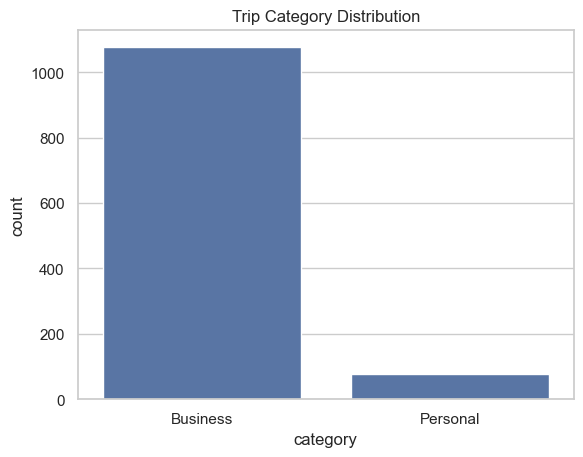

In [47]:
#trips by category
sns.countplot(x='category', data=df)
plt.title("Trip Category Distribution")
plt.show()

### 4.16 Which hours of the day are most active for trips?

Text(0, 0.5, 'Count')

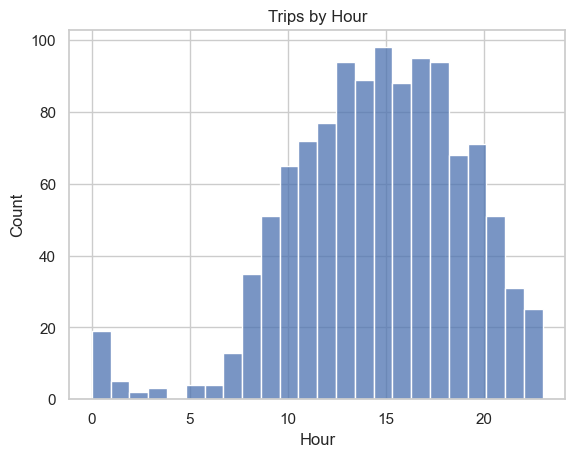

In [48]:
#trips by hour
sns.histplot(df['hours'], bins=24)
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")

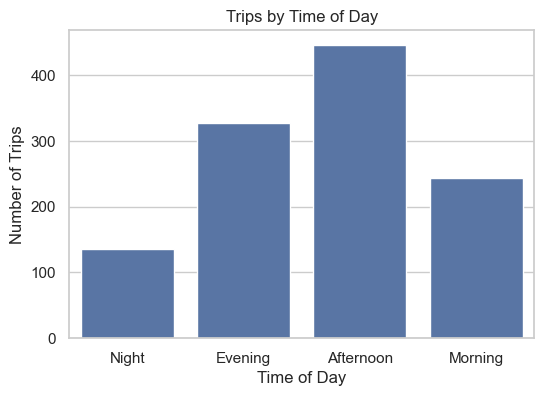

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x='time of day', data=df)
plt.title("Trips by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Trips")
plt.show()

### 4.17 Are there any outlier trips (example. trips with extremely long miles)? How many and what are they?

<Axes: xlabel='miles'>

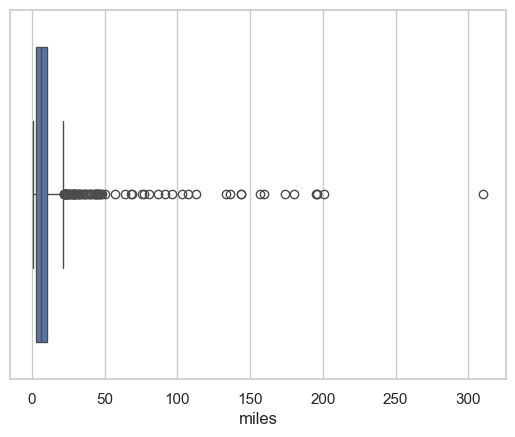

In [50]:
sns.boxplot(x=df['miles'])

In [51]:
# Detect outliers using IQR
Q1 = df['miles'].quantile(0.25)
Q3 = df['miles'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df['is_outlier'] = df['miles'] > upper_bound

print("Outliers count:", df['is_outlier'].sum())

Outliers count: 77


### 4.18 Correlation Heatmap analysis

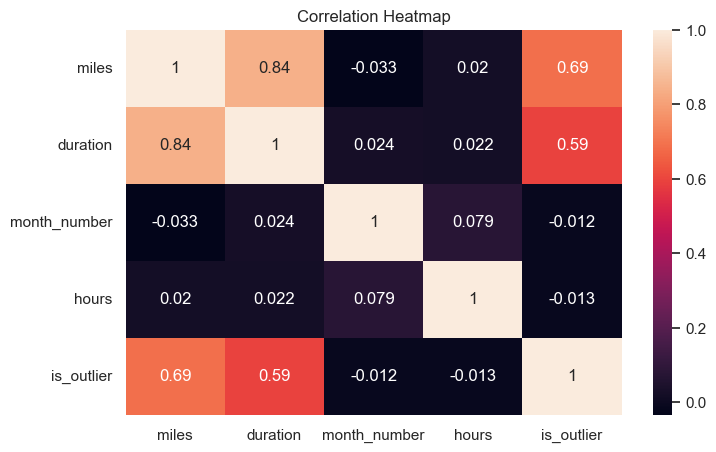

In [52]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()